
## 概要
- 元サイト：SIGNATE
- ページ：[【練習問題】銀行の顧客ターゲティング](https://user.competition.signate.jp/ja/competition/detail/?competition=092375ab3c4a43c18c8277e1fd264aa9&task=f3c678327db64f3b988fb85d8a49e5ed&tab=knowledge&knowledge=a75fea915dfb49d186b430c80312cbfa)
- 参加期間：20250927-
- 発展内容：特徴量エンジニアリング + LightGBM + ベイズ最適化


In [36]:
# 必要なライブラリのインストール
%pip install lightgbm scikit-optimize optuna japanize-matplotlib -q

print("ライブラリのインストールが完了しました")



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ライブラリのインストールが完了しました


In [ ]:
# ライブラリのインポート
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
import datetime as dt

# Jupyter環境でのみマジックコマンドを有効化
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ハイパーパラメータ調整用
try:
    import lightgbm as lgb
except OSError as e:
    print("LightGBMのインポート時にエラーが発生しました:", e)
    lgb = None

try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
except ImportError as e:
    print("scikit-optimizeのインポート時にエラーが発生しました:", e)
    BayesSearchCV = None

import time

print("✓ すべてのライブラリのインポートが完了しました")


✓ すべてのライブラリのインポートが完了しました


In [ ]:
timestamp = dt.datetime.now().strftime("%Y%m%d%H%M%S")
timestamp

'20250927052818'

## 1. データの読み込みと基本確認


In [ ]:
# データの読み込み
train = pd.read_csv('/workspaces/Desktop/competition/data/input/20250927/train.csv')
test = pd.read_csv('/workspaces/Desktop/competition/data/input/20250927/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns: {list(train.columns)}")
print(f"Test columns: {list(test.columns)}")


Train shape: (27128, 18)
Test shape: (18083, 17)

Train columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Test columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [ ]:
# 基本統計の確認
print("=== Train Data Info ===")
print(train.info())
print("\n=== Test Data Info ===")
print(test.info())

print("\n=== Train Data Head ===")
display(train.head())
print("\n=== Test Data Head ===")
display(test.head())


=== Train Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27128 entries, 0 to 27127
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         27128 non-null  int64 
 1   age        27128 non-null  int64 
 2   job        27128 non-null  object
 3   marital    27128 non-null  object
 4   education  27128 non-null  object
 5   default    27128 non-null  object
 6   balance    27128 non-null  int64 
 7   housing    27128 non-null  object
 8   loan       27128 non-null  object
 9   contact    27128 non-null  object
 10  day        27128 non-null  int64 
 11  month      27128 non-null  object
 12  duration   27128 non-null  int64 
 13  campaign   27128 non-null  int64 
 14  pdays      27128 non-null  int64 
 15  previous   27128 non-null  int64 
 16  poutcome   27128 non-null  object
 17  y          27128 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 3.7+ MB
None

=== Test Data Info ===
<class '

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,39,blue-collar,married,secondary,no,1756,yes,no,cellular,3,apr,939,1,-1,0,unknown,1
1,2,51,entrepreneur,married,primary,no,1443,no,no,cellular,18,feb,172,10,-1,0,unknown,1
2,3,36,management,single,tertiary,no,436,no,no,cellular,13,apr,567,1,595,2,failure,1
3,4,63,retired,married,secondary,no,474,no,no,cellular,25,jan,423,1,-1,0,unknown,1
4,5,31,management,single,tertiary,no,354,no,no,cellular,30,apr,502,1,9,2,success,1



=== Test Data Head ===


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1,30,management,single,tertiary,no,1028,no,no,cellular,4,feb,1294,2,-1,0,unknown
1,2,39,self-employed,single,tertiary,no,426,no,no,unknown,18,jun,1029,1,-1,0,unknown
2,3,38,technician,single,tertiary,no,-572,yes,yes,unknown,5,jun,26,24,-1,0,unknown
3,4,34,technician,single,secondary,no,-476,yes,no,unknown,27,may,92,4,-1,0,unknown
4,5,37,entrepreneur,married,primary,no,62,no,no,cellular,31,jul,404,2,-1,0,unknown


In [41]:
# 欠損値とunknownデータの確認
print("=== Train Data Missing Values ===")
print(train.isnull().sum())
print("\n=== Test Data Missing Values ===")
print(test.isnull().sum())

# unknownデータの確認
print("\n=== Unknown Data in Train ===")
for col in train.select_dtypes(include=['object']).columns:
    unknown_count = (train[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}件 ({unknown_count/len(train)*100:.2f}%)")

print("\n=== Unknown Data in Test ===")
for col in test.select_dtypes(include=['object']).columns:
    unknown_count = (test[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}件 ({unknown_count/len(test)*100:.2f}%)")


=== Train Data Missing Values ===
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== Test Data Missing Values ===
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64

=== Unknown Data in Train ===
job: 178件 (0.66%)
education: 1137件 (4.19%)
contact: 7861件 (28.98%)
poutcome: 22150件 (81.65%)

=== Unknown Data in Test ===
job: 110件 (0.61%)
education: 720件 (3.98%)
contact: 5159件 (28.53%)
poutcome: 14809件 (81.89%)


## 2. 探索的データ分析（EDA）


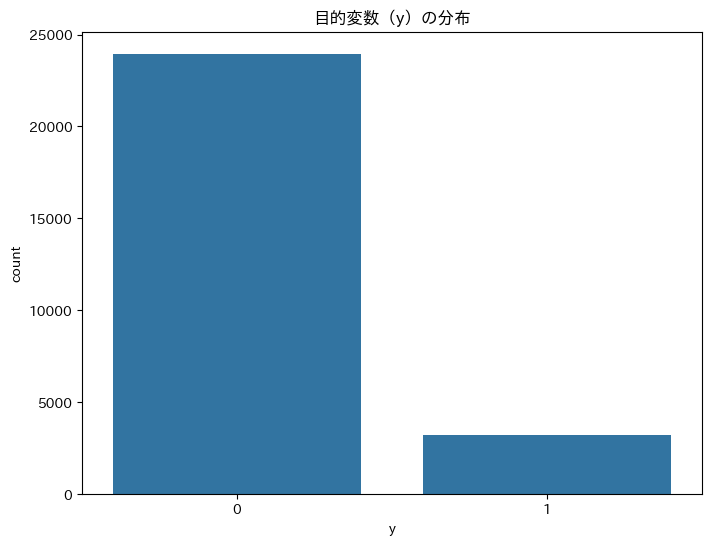

申込み率: 0.1170 (11.70%)
申込み者数: 3,174人
総顧客数: 27,128人


In [42]:
# 目的変数の分布確認
plt.figure(figsize=(8, 6))
sns.countplot(x=train['y'], data=train)
plt.title('目的変数（y）の分布')
plt.show()

print(f"申込み率: {train['y'].mean():.4f} ({train['y'].mean()*100:.2f}%)")
print(f"申込み者数: {train['y'].sum():,}人")
print(f"総顧客数: {len(train):,}人")


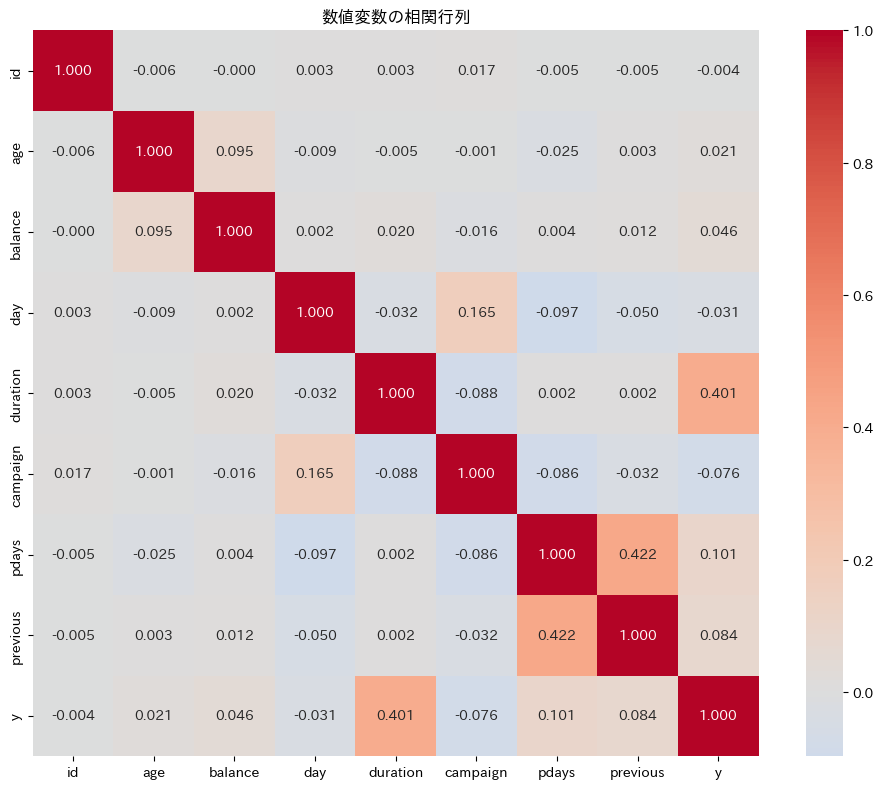

目的変数との相関係数（絶対値）:
duration    0.401390
pdays       0.100930
previous    0.083825
campaign    0.076118
balance     0.045826
day         0.031058
age         0.020892
id          0.003555
Name: y, dtype: float64


In [43]:
# 数値変数の相関分析
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlation_matrix = train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f')
plt.title('数値変数の相関行列')
plt.tight_layout()
plt.show()

# 目的変数との相関
y_correlations = correlation_matrix['y'].drop('y').abs().sort_values(ascending=False)
print("目的変数との相関係数（絶対値）:")
print(y_correlations)


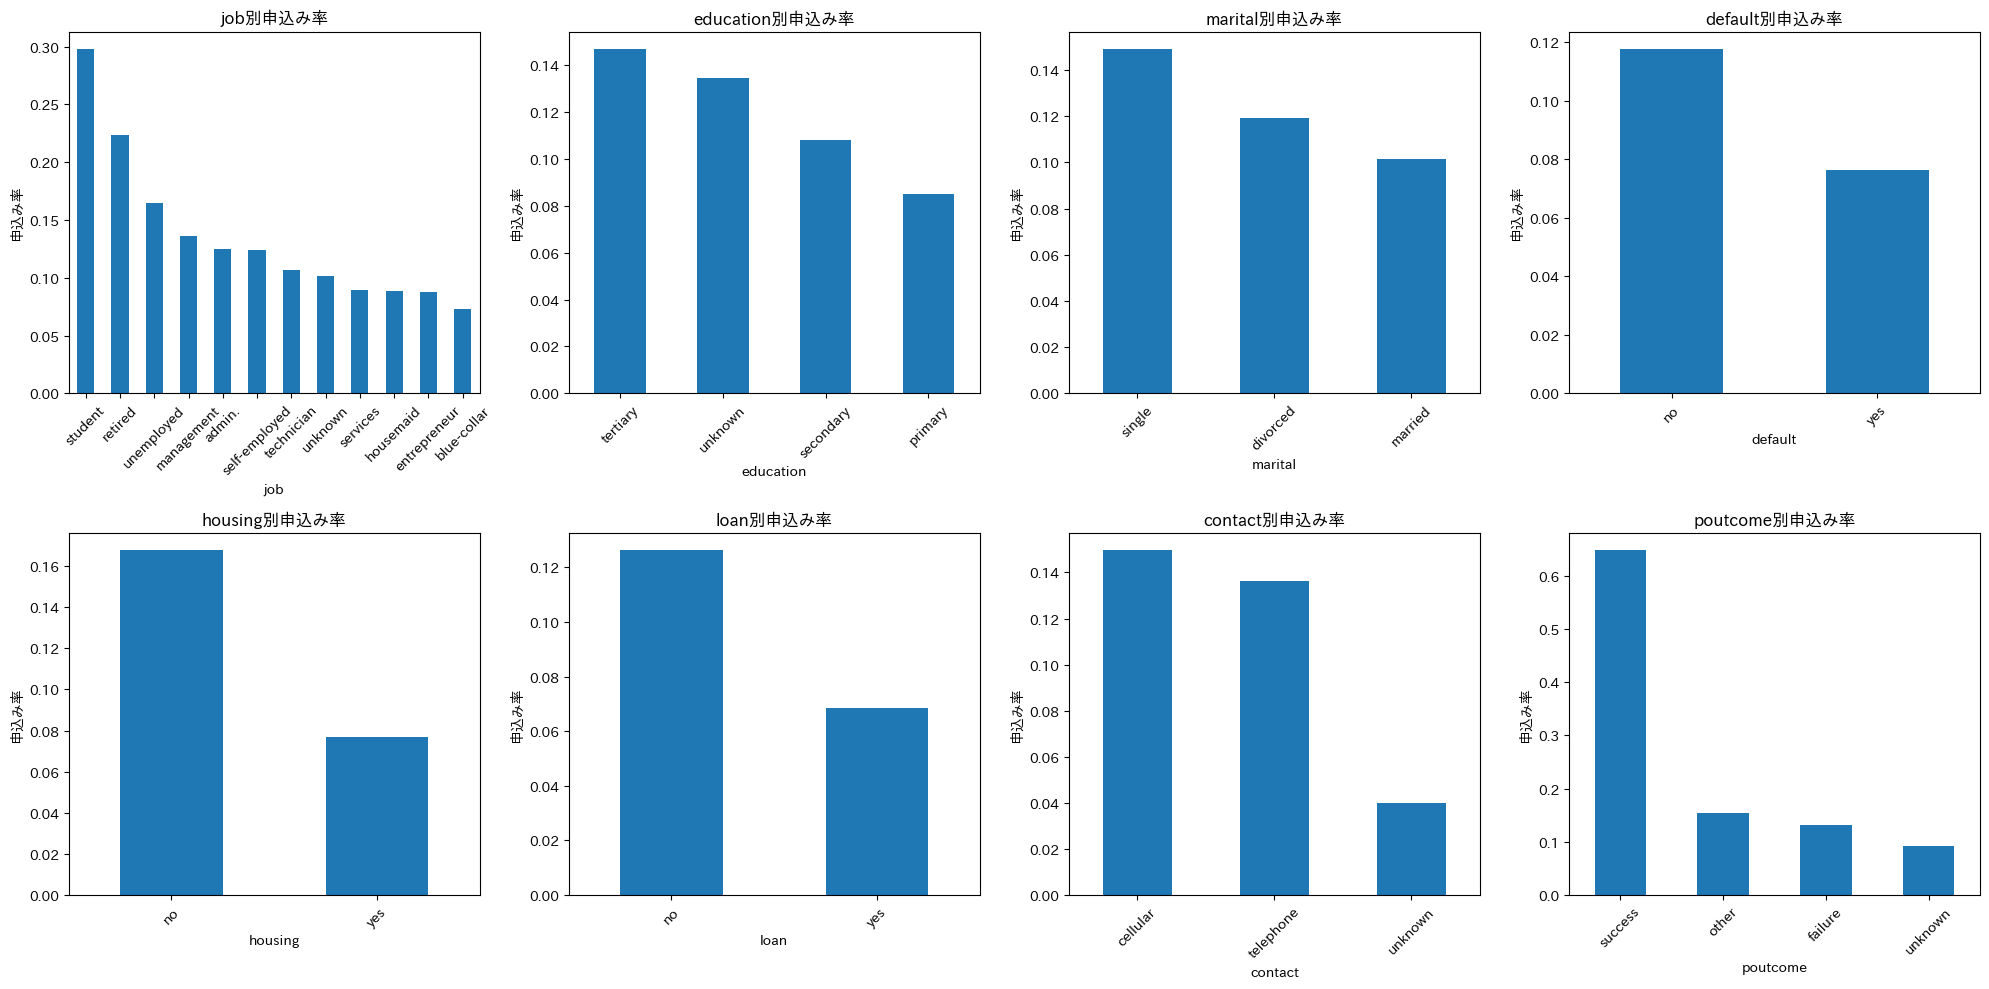

In [44]:
# カテゴリ変数と目的変数の関係
categorical_cols = ['job', 'education', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in train.columns:
        # 申込み率を計算
        conversion_rate = train.groupby(col)['y'].mean().sort_values(ascending=False)
        
        # プロット
        conversion_rate.plot.bar(ax=axes[i])
        axes[i].set_title(f'{col}別申込み率')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('申込み率')

plt.tight_layout()
plt.show()


## 3. 特徴量エンジニアリング


In [45]:
# 特徴量エンジニアリング用のデータコピー
train_fe = train.copy()
test_fe = test.copy()

print("特徴量エンジニアリングを開始します...")

# 1. 年齢のカテゴリ化
def categorize_age(age):
    if age < 30:
        return 'young'
    elif age < 50:
        return 'middle'
    else:
        return 'senior'

train_fe['age_category'] = train_fe['age'].apply(categorize_age)
test_fe['age_category'] = test_fe['age'].apply(categorize_age)
print("✓ 年齢のカテゴリ化完了")

# 2. 残高のカテゴリ化
def categorize_balance(balance):
    if balance < 0:
        return 'negative'
    elif balance < 1000:
        return 'low'
    elif balance < 5000:
        return 'medium'
    else:
        return 'high'

train_fe['balance_category'] = train_fe['balance'].apply(categorize_balance)
test_fe['balance_category'] = test_fe['balance'].apply(categorize_balance)
print("✓ 残高のカテゴリ化完了")

# 3. 期間のカテゴリ化
def categorize_duration(duration):
    if duration < 200:
        return 'short'
    elif duration < 500:
        return 'medium'
    else:
        return 'long'

train_fe['duration_category'] = train_fe['duration'].apply(categorize_duration)
test_fe['duration_category'] = test_fe['duration'].apply(categorize_duration)
print("✓ 期間のカテゴリ化完了")


特徴量エンジニアリングを開始します...
✓ 年齢のカテゴリ化完了
✓ 残高のカテゴリ化完了
✓ 期間のカテゴリ化完了


In [46]:
# 4. 複合特徴量の作成
train_fe['age_job'] = train_fe['age_category'] + '_' + train_fe['job']
test_fe['age_job'] = test_fe['age_category'] + '_' + test_fe['job']
print("✓ 年齢×職種の複合特徴量作成完了")

train_fe['education_job'] = train_fe['education'] + '_' + train_fe['job']
test_fe['education_job'] = test_fe['education'] + '_' + test_fe['job']
print("✓ 教育×職種の複合特徴量作成完了")

train_fe['loan_combination'] = train_fe['housing'] + '_' + train_fe['loan']
test_fe['loan_combination'] = test_fe['housing'] + '_' + test_fe['loan']
print("✓ ローン組み合わせ特徴量作成完了")

# 5. 数値特徴量の変換
train_fe['age_squared'] = train_fe['age'] ** 2
test_fe['age_squared'] = test_fe['age'] ** 2
print("✓ 年齢の2乗項作成完了")

train_fe['balance_log'] = np.log1p(train_fe['balance'] + abs(train_fe['balance'].min()) + 1)
test_fe['balance_log'] = np.log1p(test_fe['balance'] + abs(test_fe['balance'].min()) + 1)
print("✓ 残高の対数変換完了")

print(f"\n特徴量エンジニアリング完了 - Train: {train_fe.shape}, Test: {test_fe.shape}")


✓ 年齢×職種の複合特徴量作成完了
✓ 教育×職種の複合特徴量作成完了
✓ ローン組み合わせ特徴量作成完了
✓ 年齢の2乗項作成完了
✓ 残高の対数変換完了

特徴量エンジニアリング完了 - Train: (27128, 26), Test: (18083, 25)


## 4. データの前処理


In [47]:
# unknownデータの置換（最頻値による置換）
train_processed = train_fe.copy()
test_processed = test_fe.copy()

print("unknownデータの置換を開始します...")

for col in ['job', 'education', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']:
    if col in train_processed.columns:
        # 既知データの最頻値を取得
        mode_value = train_processed[train_processed[col] != 'unknown'][col].mode()[0]
        
        # unknownを最頻値で置換
        train_unknown_count = (train_processed[col] == 'unknown').sum()
        test_unknown_count = (test_processed[col] == 'unknown').sum()
        
        train_processed[col] = train_processed[col].replace('unknown', mode_value)
        test_processed[col] = test_processed[col].replace('unknown', mode_value)
        
        print(f"{col}: train {train_unknown_count}件, test {test_unknown_count}件 → {mode_value}で置換")

print("\n✓ unknownデータの置換が完了しました")


unknownデータの置換を開始します...
job: train 178件, test 110件 → blue-collarで置換
education: train 1137件, test 720件 → secondaryで置換
marital: train 0件, test 0件 → marriedで置換
default: train 0件, test 0件 → noで置換
housing: train 0件, test 0件 → yesで置換
loan: train 0件, test 0件 → noで置換
contact: train 7861件, test 5159件 → cellularで置換
poutcome: train 22150件, test 14809件 → failureで置換

✓ unknownデータの置換が完了しました


In [48]:
# 特徴量選択
use_columns = [
    'age', 'balance', 'duration', 'campaign', 'pdays', 'previous',
    'job', 'education', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome',
    'age_category', 'balance_category', 'duration_category',
    'age_job', 'education_job', 'loan_combination',
    'age_squared', 'balance_log'
]

y = train_processed['y']
X_train = train_processed[use_columns]
X_test = test_processed[use_columns]

print(f"使用特徴量数: {len(use_columns)}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


使用特徴量数: 22
Train shape: (27128, 22)
Test shape: (18083, 22)


In [49]:
# ダミー変数化
X_train_dummy = pd.get_dummies(X_train, drop_first=True)
X_test_dummy = pd.get_dummies(X_test, drop_first=True)

# 列の整合性を確保
missing_cols = set(X_train_dummy.columns) - set(X_test_dummy.columns)
for col in missing_cols:
    X_test_dummy[col] = 0

# 列の順序を統一
X_test_dummy = X_test_dummy[X_train_dummy.columns]

print(f"ダミー変数化後 - Train: {X_train_dummy.shape}, Test: {X_test_dummy.shape}")
print(f"特徴量数: {X_train_dummy.shape[1]}")


ダミー変数化後 - Train: (27128, 119), Test: (18083, 119)
特徴量数: 119


## 5. ベースラインモデル（ロジスティック回帰）


In [50]:
# データの分割
X_train_split, X_valid_split, y_train_split, y_valid_split = train_test_split(
    X_train_dummy, y, test_size=0.2, random_state=82, stratify=y
)

print(f"データ分割完了 - Train: {X_train_split.shape}, Valid: {X_valid_split.shape}")


データ分割完了 - Train: (21702, 119), Valid: (5426, 119)


In [51]:
# ロジスティック回帰（ベースライン）
lr_baseline = LogisticRegression(random_state=82, class_weight='balanced', max_iter=1000)
lr_baseline.fit(X_train_split, y_train_split)

# 予測
train_pred_lr = lr_baseline.predict(X_train_split)
valid_pred_lr = lr_baseline.predict(X_valid_split)
train_proba_lr = lr_baseline.predict_proba(X_train_split)[:, 1]
valid_proba_lr = lr_baseline.predict_proba(X_valid_split)[:, 1]

# 評価
train_acc_lr = accuracy_score(y_train_split, train_pred_lr)
valid_acc_lr = accuracy_score(y_valid_split, valid_pred_lr)
train_auc_lr = roc_auc_score(y_train_split, train_proba_lr)
valid_auc_lr = roc_auc_score(y_valid_split, valid_proba_lr)

print("=== ロジスティック回帰（ベースライン）===")
print(f"Train Accuracy: {train_acc_lr:.4f}")
print(f"Valid Accuracy: {valid_acc_lr:.4f}")
print(f"Train AUC: {train_auc_lr:.4f}")
print(f"Valid AUC: {valid_auc_lr:.4f}")


=== ロジスティック回帰（ベースライン）===
Train Accuracy: 0.8233
Valid Accuracy: 0.8236
Train AUC: 0.8913
Valid AUC: 0.8889


## 6. LightGBM + ベイズ最適化


In [52]:
# LightGBMのlibgomp.so.1エラー対策
# Google Colabや一部のLinux環境ではlibgomp.so.1が必要です。未インストールの場合は下記でインストールしてください。
import os
import sys

def install_libgomp():
    try:
        # Ubuntu/Debian系
        if os.system("apt-get --version") == 0:
            print("libgomp1をインストールします...")
            os.system("apt-get update")
            os.system("apt-get install -y libgomp1")
        # RedHat/CentOS系
        elif os.system("yum --version") == 0:
            print("libgompをインストールします...")
            os.system("yum install -y libgomp")
        else:
            print("libgompの自動インストールに未対応の環境です。手動でlibgomp.so.1をインストールしてください。")
    except Exception as e:
        print("libgompインストール時にエラー:", e)

# libgomp.so.1が存在しない場合のみインストール
if not os.path.exists("/usr/lib/x86_64-linux-gnu/libgomp.so.1") and not os.path.exists("/usr/lib64/libgomp.so.1"):
    install_libgomp()

# 必要なライブラリのインポート
from skopt.space import Integer, Real
from lightgbm import LGBMClassifier

# LightGBMのパラメータ空間を定義
lgb_param_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'num_leaves': Integer(10, 200),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'reg_alpha': Real(0.0, 5.0),
    'reg_lambda': Real(0.0, 5.0),
    'min_child_samples': Integer(10, 50),
    'min_child_weight': Real(0.001, 5.0, prior='log-uniform')
}

# LightGBMモデルの初期化
lgb_model = LGBMClassifier(
    random_state=82,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1
)

print("LightGBMのパラメータ空間を定義しました")


apt 3.0.3 (arm64)
Supported modules:
*Ver: Standard .deb
*Pkg:  Debian dpkg interface (Priority 30)
 Pkg:  Debian APT solver interface (Priority -1000)
 Pkg:  Debian APT planner interface (Priority -1000)
 S.L: 'deb' Debian binary tree
 S.L: 'deb-src' Debian source tree
 Idx: Debian Source Index
 Idx: Debian Package Index
 Idx: Debian Translation Index
 Idx: Debian dpkg status file
 Idx: Debian deb file
 Idx: Debian dsc file
 Idx: Debian control file
 Idx: EDSP scenario file
 Idx: EIPP scenario file
libgomp1をインストールします...
Hit:1 http://deb.debian.org/debian trixie InRelease
Hit:2 http://deb.debian.org/debian trixie-updates InRelease
Hit:3 http://deb.debian.org/debian-security trixie-security InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
libgomp1 is already the newest version (14.2.0-19).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
LightGBMのパラメータ空間を定義しました


In [53]:
# ベイズ最適化の実行
print("ベイズ最適化を開始します（20回の試行）...")
start_time = time.time()

bayes_search = BayesSearchCV(
    lgb_model,
    lgb_param_space,
    n_iter=20,  # 20回の試行
    cv=3,       # 3-fold CV
    scoring='roc_auc',
    random_state=82,
    n_jobs=-1,
    verbose=1
)

bayes_search.fit(X_train_split, y_train_split)

end_time = time.time()
print(f"\n✓ ベイズ最適化完了: {end_time - start_time:.2f}秒")

# 最適なパラメータを表示
print("\n=== 最適なパラメータ ===")
best_params = bayes_search.best_params_
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\n最良のCVスコア: {bayes_search.best_score_:.4f}")


ベイズ最適化を開始します（20回の試行）...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [54]:
# 最適化されたモデルの評価
best_lgb_model = bayes_search.best_estimator_

# 検証データでの予測
valid_pred_lgb = best_lgb_model.predict(X_valid_split)
valid_proba_lgb = best_lgb_model.predict_proba(X_valid_split)[:, 1]

# 評価
valid_acc_lgb = accuracy_score(y_valid_split, valid_pred_lgb)
valid_auc_lgb = roc_auc_score(y_valid_split, valid_proba_lgb)

print("=== 最適化されたLightGBM ===")
print(f"Valid Accuracy: {valid_acc_lgb:.4f}")
print(f"Valid AUC: {valid_auc_lgb:.4f}")

# ベースラインとの比較
print("\n=== ベースラインとの比較 ===")
print(f"ロジスティック回帰 Valid AUC: {valid_auc_lr:.4f}")
print(f"LightGBM + ベイズ最適化 Valid AUC: {valid_auc_lgb:.4f}")
print(f"改善幅: {valid_auc_lgb - valid_auc_lr:.4f}")


=== 最適化されたLightGBM ===
Valid Accuracy: 0.8286
Valid AUC: 0.8969

=== ベースラインとの比較 ===
ロジスティック回帰 Valid AUC: 0.8889
LightGBM + ベイズ最適化 Valid AUC: 0.8969
改善幅: 0.0080


=== 特徴量重要度（上位15位）===
                           feature  importance
2                         duration         355
0                              age         157
4                            pdays         155
1                          balance         154
3                         campaign          97
7                      balance_log          72
27                poutcome_success          56
23                     housing_yes          54
6                      age_squared          44
92   education_job_tertiary_admin.          41
5                         previous          31
20                 marital_married          28
80  education_job_secondary_admin.          24
24                        loan_yes          24
25               contact_telephone          23


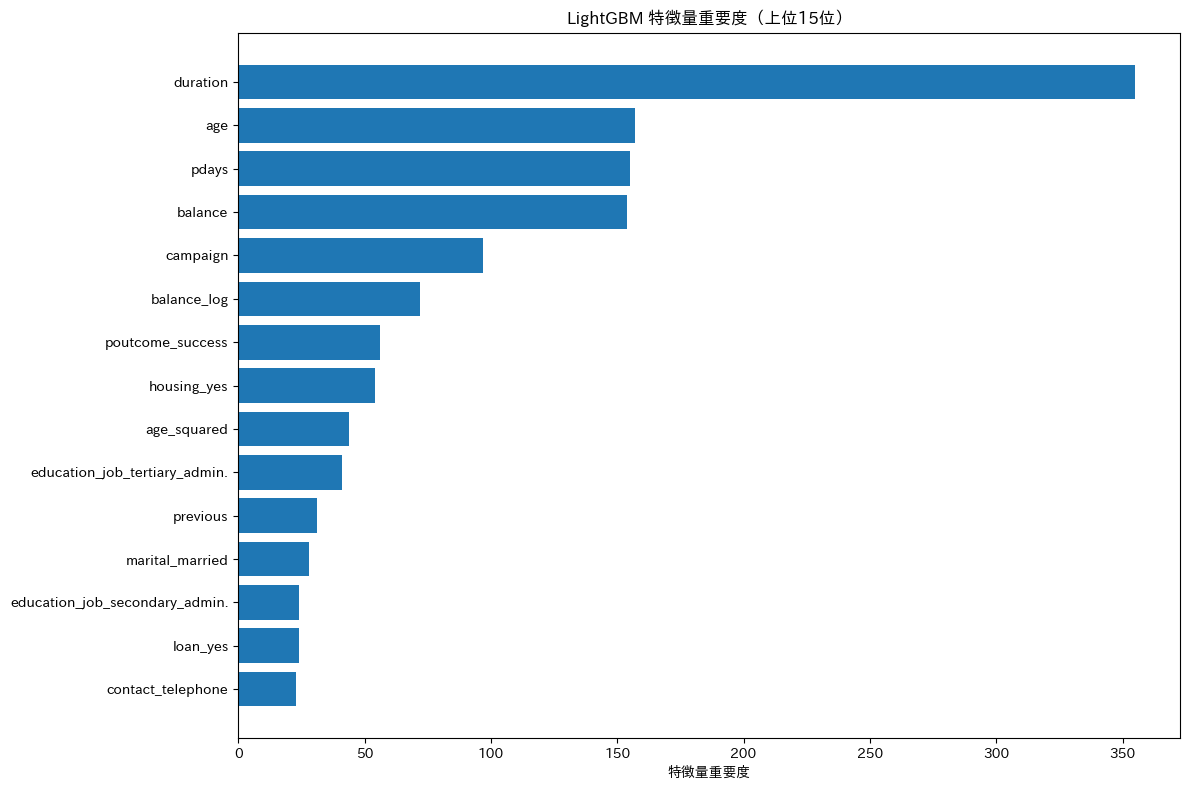

In [55]:
# 特徴量重要度の表示
feature_importance = pd.DataFrame({
    'feature': X_train_split.columns,
    'importance': best_lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== 特徴量重要度（上位15位）===")
print(feature_importance.head(15))

# 特徴量重要度の可視化
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('特徴量重要度')
plt.title('LightGBM 特徴量重要度（上位15位）')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


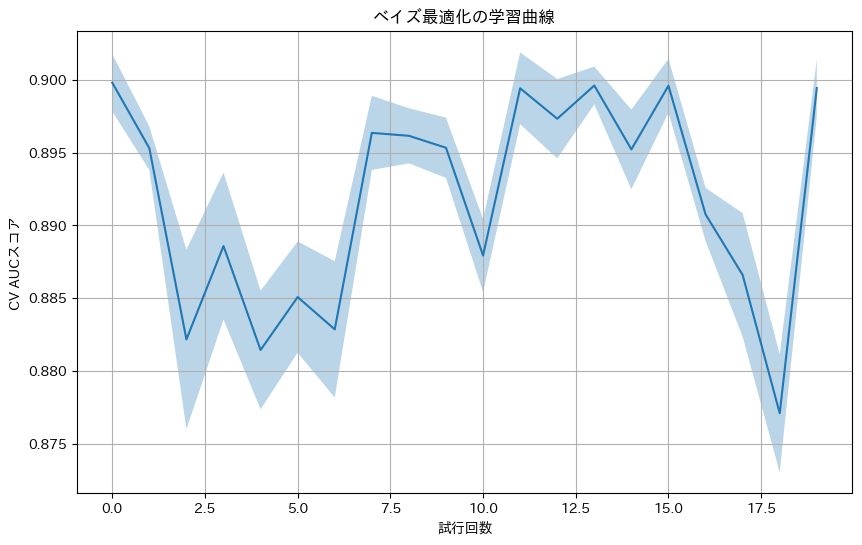

In [56]:
# ベイズ最適化の学習曲線
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.fill_between(range(len(bayes_search.cv_results_['mean_test_score'])),
                 bayes_search.cv_results_['mean_test_score'] - bayes_search.cv_results_['std_test_score'],
                 bayes_search.cv_results_['mean_test_score'] + bayes_search.cv_results_['std_test_score'],
                 alpha=0.3)
plt.xlabel('試行回数')
plt.ylabel('CV AUCスコア')
plt.title('ベイズ最適化の学習曲線')
plt.grid(True)
plt.show()


## 7. 最終予測と提出ファイル作成


In [57]:
# LightGBMがインポートできているか確認し、エラーを回避
try:
    import lightgbm as lgb
except ImportError:
    print("lightgbmパッケージがインストールされていません。'pip install lightgbm'でインストールしてください。")
else:
    # 全データで再学習（最適化されたパラメータで）
    final_lgb_model = lgb.LGBMClassifier(**best_params, random_state=82, class_weight='balanced', verbose=-1)
    final_lgb_model.fit(X_train_dummy, y)

    print("✓ 全データでの再学習が完了しました")

    # テストデータの予測
    final_predictions = final_lgb_model.predict_proba(X_test_dummy)[:, 1]

    print(f"予測値の統計:")
    print(f"  平均: {final_predictions.mean():.4f}")
    print(f"  最小値: {final_predictions.min():.4f}")
    print(f"  最大値: {final_predictions.max():.4f}")
    print(f"  標準偏差: {final_predictions.std():.4f}")


✓ 全データでの再学習が完了しました
予測値の統計:
  平均: 0.3052
  最小値: 0.0016
  最大値: 0.9907
  標準偏差: 0.2985


In [1]:
# 提出ファイルの作成（保存先をタイムスタンプ付きパスに変更）
import datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
output_path = f'/workspaces/Desktop/competition/data/output/20250927/{timestamp}.csv'

submit = pd.read_csv('/workspaces/Desktop/competition/data/input/20250927/submit_sample.csv', header=None)
submit[1] = final_predictions
submit.to_csv(output_path, header=None, index=False)

print(f"✓ 提出ファイルが作成されました: {output_path}")
print(f"提出ファイルの形状: {submit.shape}")
print("\n提出ファイルの先頭5行:")
print(submit.head())


NameError: name 'pd' is not defined

## 8. まとめ

### 実施した改善点

1. **特徴量エンジニアリング**
   - 年齢、残高、期間のカテゴリ化
   - 複合特徴量の作成（年齢×職種、教育×職種など）
   - 数値特徴量の変換（年齢の2乗項、残高の対数変換）

2. **unknownデータの適切な処理**
   - 最頻値による置換戦略
   - データの整合性を保持

3. **LightGBM + ベイズ最適化**
   - 高性能な勾配ブースティングアルゴリズム
   - 効率的なハイパーパラメータ探索
   - 特徴量重要度による解釈性の向上

4. **包括的な評価**
   - ベースラインとの性能比較
   - 特徴量重要度の可視化
   - 学習曲線による最適化過程の確認

### 期待される効果

- **精度向上**: 特徴量エンジニアリングとベイズ最適化による性能向上
- **効率性**: LightGBMの高速学習とメモリ効率
- **解釈性**: 特徴量重要度によるモデルの理解
- **汎化性能**: 適切な正則化による過学習の防止
